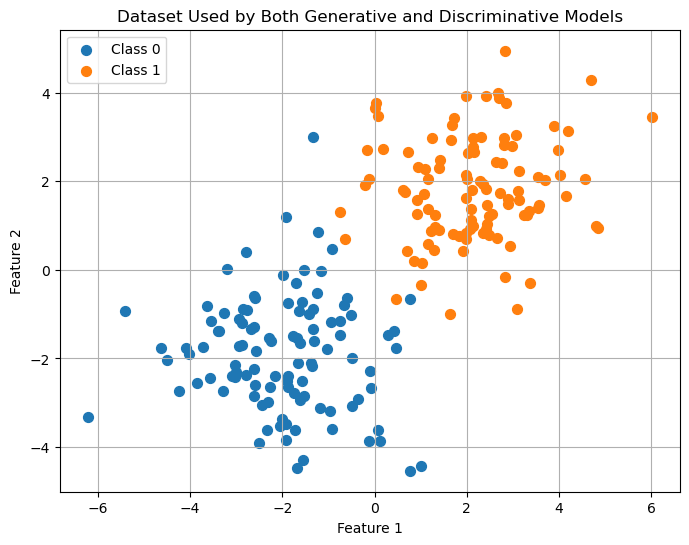


GAUSSIAN NAIVE BAYES

Class means:
[[-1.96663915 -1.89360857]
 [ 2.14639914  1.82940979]]

Class variances:
[[1.74056034 1.67948811]
 [1.59073174 1.38415694]]

Class prior probabilities:
[0.5 0.5]

Accuracy: 0.989

LOGISTIC REGRESSION

Weights:
[[2.09345907 1.35357346]]

Bias:
[-0.17673532]

Accuracy: 0.989

LINEAR SVM

Accuracy: 0.989

KNN

Accuracy: 0.989

LINEAR DISCRIMINANT ANALYSIS

Class means:
[[-1.96663915 -1.89360857]
 [ 2.14639914  1.82940979]]

Accuracy: 0.989


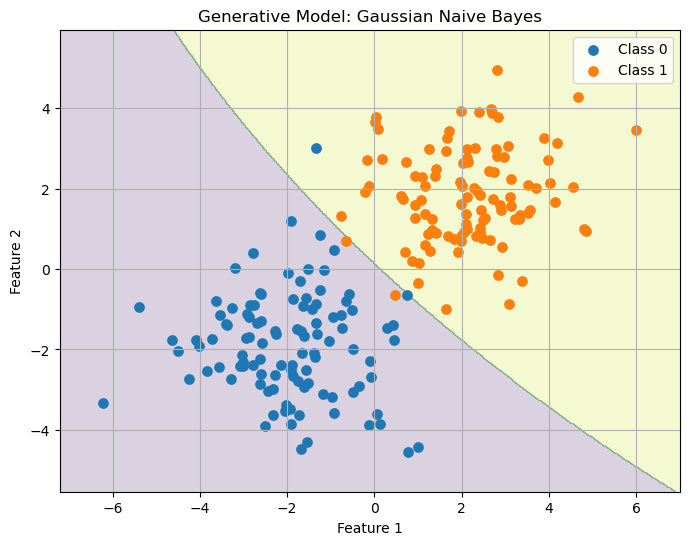

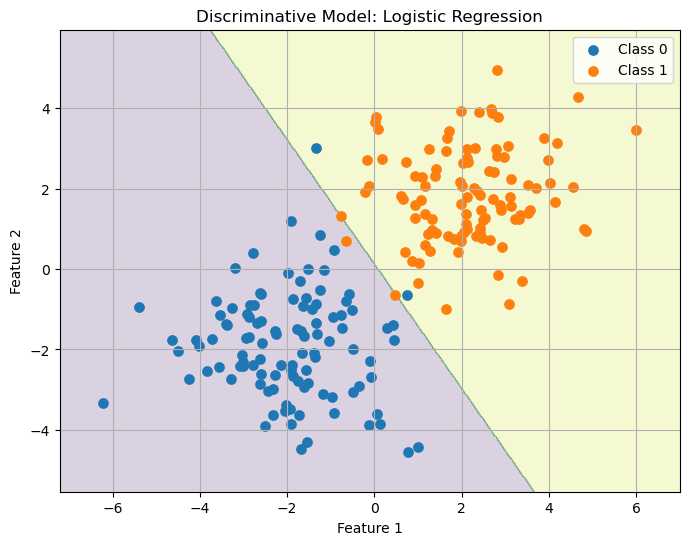

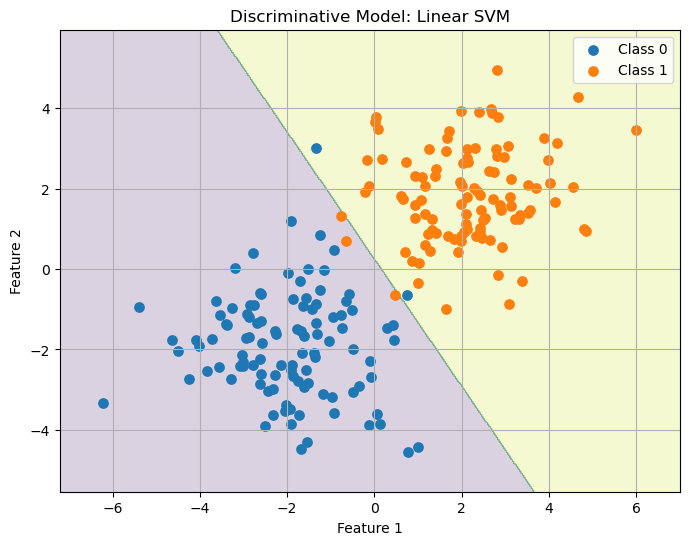

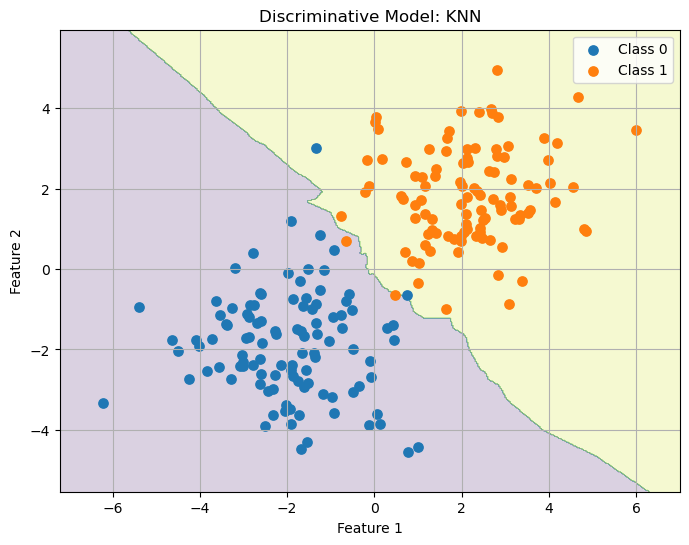

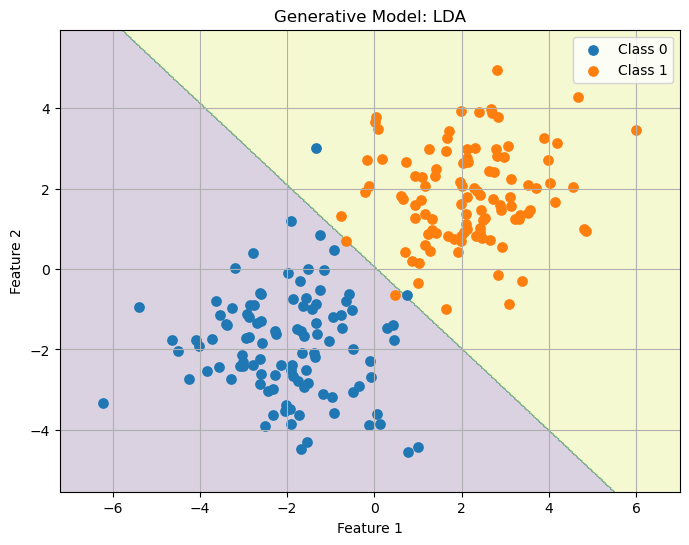

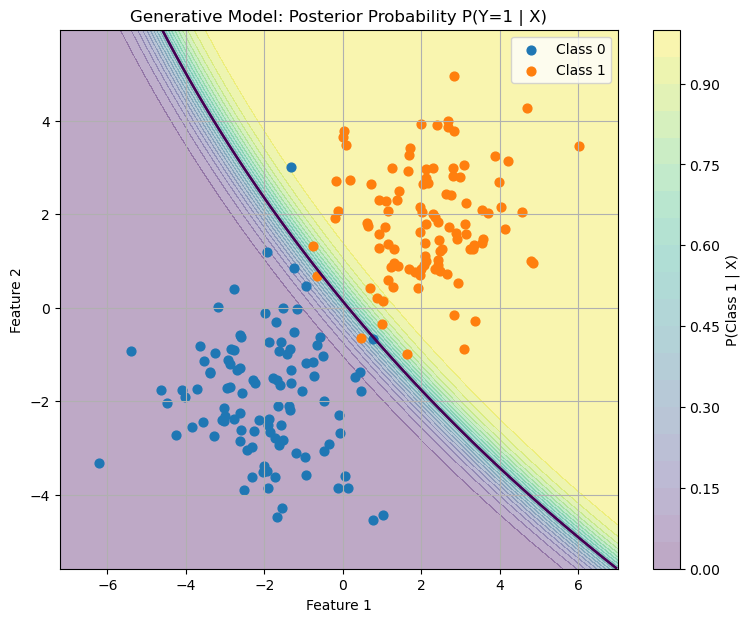


PROBABILITY FOR ONE TEST SAMPLE

Test sample: [[2.51278779 1.45272017]]

Generative model:
Gaussian Naive Bayes P(Y|X) = [[1.06633359e-04 9.99893367e-01]]
LDA P(Y|X) = [[8.18337473e-05 9.99918166e-01]]

Discriminative model:
Logistic Regression P(Y|X) = [[8.66616923e-04 9.99133383e-01]]

GAUSSIAN MIXTURE MODEL

Gaussian means:
[[-1.96795885 -1.95655021]
 [ 2.07944738  1.82850527]]

Gaussian covariance matrices:
[[[ 1.79816361 -0.16189369]
  [-0.16189369  1.43304273]]

 [[ 1.80316988  0.18567516]
  [ 0.18567516  1.40030506]]]

Mixture weights:
[0.49156602 0.50843398]


C:\Users\palan\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\palan\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\palan\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\palan\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\palan\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
  

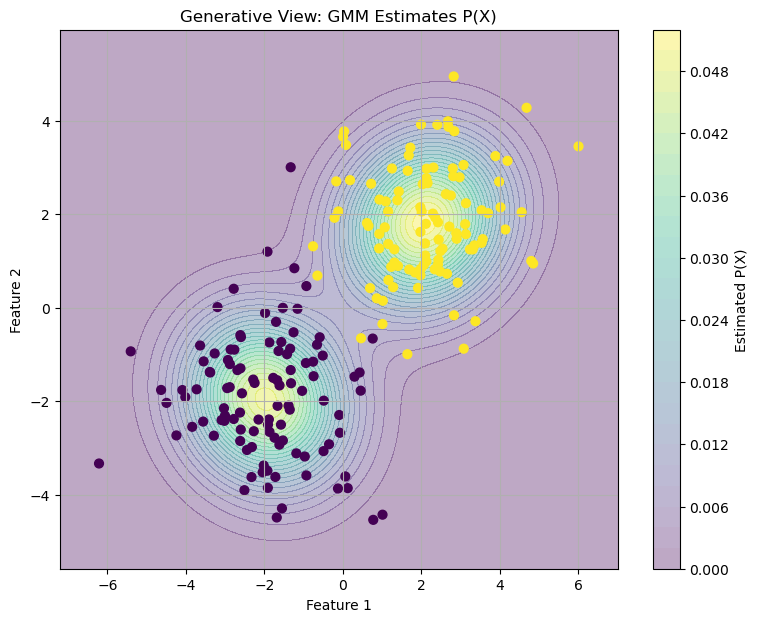

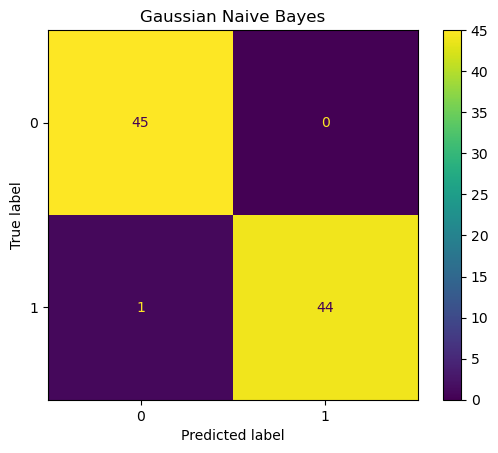

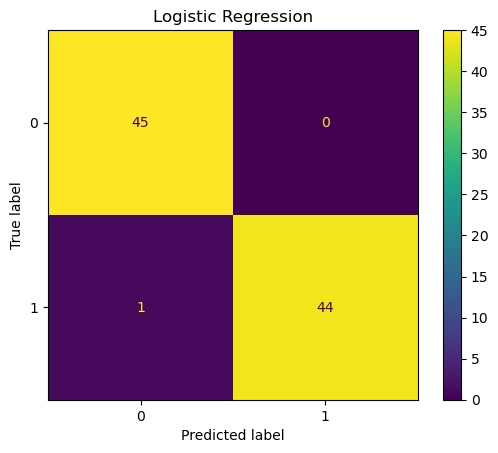

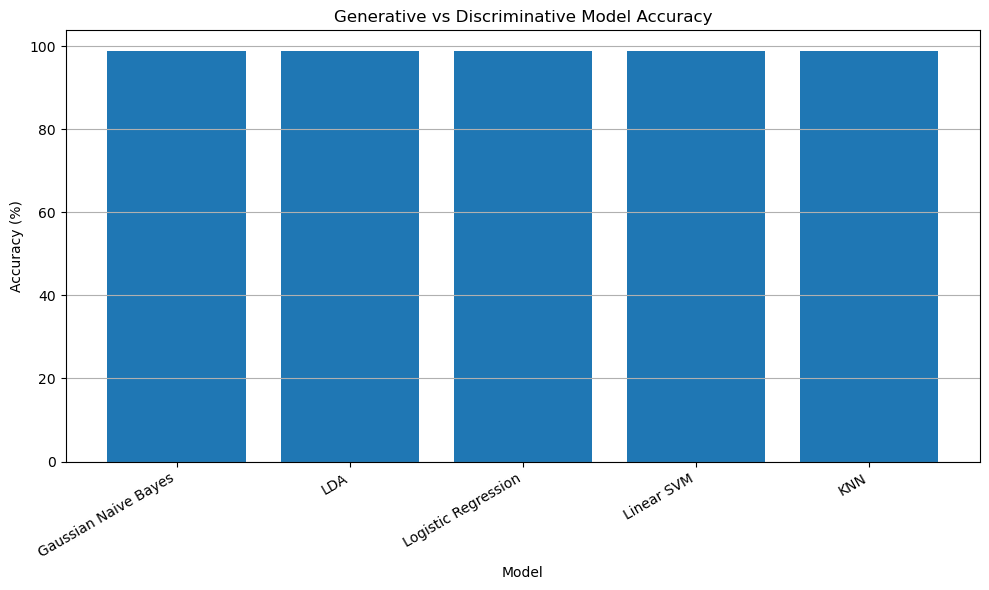


GENERATIVE vs DISCRIMINATIVE MODELS

GENERATIVE MODELS
-----------------

Learn the data-generating process.

Typically model:

        P(X | Y)
        P(Y)

Then use Bayes theorem:

        P(Y | X)
        =
        P(X | Y)P(Y)
        ----------------
              P(X)


Examples:

        Gaussian Naive Bayes
        LDA
        Gaussian Mixture Model


DISCRIMINATIVE MODELS
---------------------

Focus on separating classes.

They may learn:

        P(Y | X)

or directly learn:

        f(X)


Examples:

        Logistic Regression
        SVM
        KNN


MAIN DIFFERENCE
---------------

Generative:

        "How was this data generated?"

Discriminative:

        "How should I separate/classify this data?"





In [1]:
# ============================================================
# PROBABILISTIC GENERATIVE vs DISCRIMINATIVE MODELS
# ============================================================
#
# This program explains the fundamental difference between:
#
#       GENERATIVE MODELS
#              vs
#       DISCRIMINATIVE MODELS
#
# ------------------------------------------------------------
# GENERATIVE MODELS
# ------------------------------------------------------------
#
# Learn:
#
#       P(X | Y)
#       P(Y)
#
# and use Bayes theorem:
#
#       P(Y | X)
#       =
#       P(X | Y) P(Y) / P(X)
#
# Examples:
#
#       Gaussian Naive Bayes
#       LDA
#       Gaussian Mixture Model
#
# ------------------------------------------------------------
# DISCRIMINATIVE MODELS
# ------------------------------------------------------------
#
# Directly learn:
#
#       P(Y | X)
#
# or learn a decision function:
#
#       f(X)
#
# Examples:
#
#       Logistic Regression
#       SVM
#       KNN
#
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np

import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

from sklearn.datasets import make_blobs

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 2. CREATE DATASET
# ============================================================
#
# We use the SAME dataset for all models.
#
# This is important for a fair conceptual comparison.
#
# ============================================================

X, y = make_blobs(
    n_samples=300,
    centers=[
        [-2, -2],
        [2, 2]
    ],
    cluster_std=[
        [1.3, 1.3],
        [1.3, 1.3]
    ] if False else 1.3,
    random_state=42
)


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.30,

    random_state=42,

    stratify=y
)


# ============================================================
# 4. VISUALIZE DATA
# ============================================================

plt.figure(figsize=(8, 6))


plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    label="Class 0",
    s=50
)


plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    label="Class 1",
    s=50
)


plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title(
    "Dataset Used by Both Generative and Discriminative Models"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# PART A
# GENERATIVE MODEL 1
# GAUSSIAN NAIVE BAYES
# ============================================================


# ============================================================
# 5. CREATE GAUSSIAN NAIVE BAYES MODEL
# ============================================================
#
# Gaussian Naive Bayes estimates:
#
#       P(X | Y)
#
# and:
#
#       P(Y)
#
# Then applies Bayes theorem.
#
# ------------------------------------------------------------
#
# The "naive" assumption is that features are conditionally
# independent given the class.
#
# ============================================================

gnb = GaussianNB()


# ============================================================
# 6. TRAIN MODEL
# ============================================================

gnb.fit(
    X_train,
    y_train
)


# ============================================================
# 7. DISPLAY LEARNED PARAMETERS
# ============================================================

print("\n==============================================")
print("GAUSSIAN NAIVE BAYES")
print("==============================================")


print(
    "\nClass means:"
)

print(
    gnb.theta_
)


print(
    "\nClass variances:"
)

print(
    gnb.var_
)


print(
    "\nClass prior probabilities:"
)

print(
    gnb.class_prior_
)


# ============================================================
# 8. GAUSSIAN NAIVE BAYES PREDICTION
# ============================================================

gnb_predictions = gnb.predict(
    X_test
)


print(
    "\nAccuracy:",
    round(
        accuracy_score(
            y_test,
            gnb_predictions
        ),
        3
    )
)


# ============================================================
# PART B
# DISCRIMINATIVE MODEL 1
# LOGISTIC REGRESSION
# ============================================================


# ============================================================
# 9. CREATE LOGISTIC REGRESSION
# ============================================================
#
# Logistic regression directly models:
#
#       P(Y | X)
#
# using:
#
#       P(Y=1|X)
#       =
#       1 / (1 + exp(-(w^T X + b)))
#
# ============================================================

logistic = LogisticRegression()


# ============================================================
# 10. TRAIN
# ============================================================

logistic.fit(
    X_train,
    y_train
)


# ============================================================
# 11. DISPLAY PARAMETERS
# ============================================================

print("\n==============================================")
print("LOGISTIC REGRESSION")
print("==============================================")


print(
    "\nWeights:"
)

print(
    logistic.coef_
)


print(
    "\nBias:"
)

print(
    logistic.intercept_
)


# ============================================================
# 12. PREDICT
# ============================================================

logistic_predictions = logistic.predict(
    X_test
)


print(
    "\nAccuracy:",
    round(
        accuracy_score(
            y_test,
            logistic_predictions
        ),
        3
    )
)


# ============================================================
# PART C
# DISCRIMINATIVE MODEL 2
# LINEAR SVM
# ============================================================


# ============================================================
# 13. CREATE LINEAR SVM
# ============================================================
#
# SVM learns a decision function:
#
#       f(X) = w^T X + b
#
# It does NOT explicitly model:
#
#       P(X | Y)
#
# ============================================================

linear_svm = SVC(
    kernel="linear",
    probability=True
)


# ============================================================
# 14. TRAIN
# ============================================================

linear_svm.fit(
    X_train,
    y_train
)


# ============================================================
# 15. PREDICT
# ============================================================

svm_predictions = linear_svm.predict(
    X_test
)


print("\n==============================================")
print("LINEAR SVM")
print("==============================================")


print(
    "\nAccuracy:",
    round(
        accuracy_score(
            y_test,
            svm_predictions
        ),
        3
    )
)


# ============================================================
# PART D
# KNN
# ============================================================
#
# KNN is a discriminative/non-parametric classifier in the
# sense that it predicts class membership from the observed
# feature space rather than explicitly modeling a class-
# conditional density P(X|Y).
#
# ============================================================


knn = KNeighborsClassifier(
    n_neighbors=5
)


knn.fit(
    X_train,
    y_train
)


knn_predictions = knn.predict(
    X_test
)


print("\n==============================================")
print("KNN")
print("==============================================")


print(
    "\nAccuracy:",
    round(
        accuracy_score(
            y_test,
            knn_predictions
        ),
        3
    )
)


# ============================================================
# PART E
# GENERATIVE MODEL 2
# LINEAR DISCRIMINANT ANALYSIS
# ============================================================
#
# Important:
#
# Despite its name, LDA is generally considered a
# generative probabilistic classifier.
#
# It models:
#
#       P(X | Y)
#
# using Gaussian class-conditional distributions with a
# shared covariance matrix.
#
# ============================================================


lda = LinearDiscriminantAnalysis()


lda.fit(
    X_train,
    y_train
)


lda_predictions = lda.predict(
    X_test
)


print("\n==============================================")
print("LINEAR DISCRIMINANT ANALYSIS")
print("==============================================")


print(
    "\nClass means:"
)

print(
    lda.means_
)


print(
    "\nAccuracy:",
    round(
        accuracy_score(
            y_test,
            lda_predictions
        ),
        3
    )
)


# ============================================================
# PART F
# FUNCTION TO VISUALIZE DECISION BOUNDARY
# ============================================================

def plot_model_boundary(
    model,
    X,
    y,
    title
):


    # --------------------------------------------------------
    # Determine plotting range
    # --------------------------------------------------------

    x_min = X[:, 0].min() - 1

    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1

    y_max = X[:, 1].max() + 1


    # --------------------------------------------------------
    # Create a grid
    # --------------------------------------------------------

    xx, yy = np.meshgrid(

        np.linspace(
            x_min,
            x_max,
            500
        ),

        np.linspace(
            y_min,
            y_max,
            500
        )
    )


    # Convert grid to samples
    grid = np.c_[

        xx.ravel(),

        yy.ravel()
    ]


    # --------------------------------------------------------
    # Predict grid
    # --------------------------------------------------------

    predictions = model.predict(
        grid
    )


    predictions = predictions.reshape(
        xx.shape
    )


    # --------------------------------------------------------
    # Plot decision regions
    # --------------------------------------------------------

    plt.figure(figsize=(8, 6))


    plt.contourf(

        xx,

        yy,

        predictions,

        alpha=0.20
    )


    # Plot Class 0
    plt.scatter(

        X[y == 0, 0],

        X[y == 0, 1],

        label="Class 0",

        s=45
    )


    # Plot Class 1
    plt.scatter(

        X[y == 1, 0],

        X[y == 1, 1],

        label="Class 1",

        s=45
    )


    plt.xlabel("Feature 1")

    plt.ylabel("Feature 2")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.show()


# ============================================================
# 17. VISUALIZE GENERATIVE MODEL
# ============================================================

plot_model_boundary(

    gnb,

    X_train,

    y_train,

    "Generative Model: Gaussian Naive Bayes"
)


# ============================================================
# 18. VISUALIZE DISCRIMINATIVE MODEL
# ============================================================

plot_model_boundary(

    logistic,

    X_train,

    y_train,

    "Discriminative Model: Logistic Regression"
)


# ============================================================
# 19. VISUALIZE LINEAR SVM
# ============================================================

plot_model_boundary(

    linear_svm,

    X_train,

    y_train,

    "Discriminative Model: Linear SVM"
)


# ============================================================
# 20. VISUALIZE KNN
# ============================================================

plot_model_boundary(

    knn,

    X_train,

    y_train,

    "Discriminative Model: KNN"
)


# ============================================================
# 21. VISUALIZE LDA
# ============================================================

plot_model_boundary(

    lda,

    X_train,

    y_train,

    "Generative Model: LDA"
)


# ============================================================
# PART G
# VISUALIZE GENERATIVE DISTRIBUTIONS
# ============================================================
#
# This is one of the most important visualizations.
#
# A generative model attempts to understand how the data
# are distributed within each class.
#
# ============================================================


# ============================================================
# 22. CREATE GRID
# ============================================================

x_min = X[:, 0].min() - 1

x_max = X[:, 0].max() + 1

y_min = X[:, 1].min() - 1

y_max = X[:, 1].max() + 1


xx, yy = np.meshgrid(

    np.linspace(
        x_min,
        x_max,
        300
    ),

    np.linspace(
        y_min,
        y_max,
        300
    )
)


grid = np.c_[

    xx.ravel(),

    yy.ravel()
]


# ============================================================
# 23. CALCULATE GENERATIVE MODEL PROBABILITIES
# ============================================================
#
# Gaussian Naive Bayes gives:
#
#       P(Class 0 | X)
#       P(Class 1 | X)
#
# ============================================================

probabilities = gnb.predict_proba(
    grid
)


prob_class_1 = probabilities[
    :, 1
].reshape(
    xx.shape
)


# ============================================================
# 24. VISUALIZE POSTERIOR PROBABILITY
# ============================================================

plt.figure(figsize=(9, 7))


plt.contourf(

    xx,

    yy,

    prob_class_1,

    levels=20,

    alpha=0.35
)


plt.colorbar(
    label="P(Class 1 | X)"
)


plt.scatter(

    X_train[y_train == 0, 0],

    X_train[y_train == 0, 1],

    label="Class 0",

    s=40
)


plt.scatter(

    X_train[y_train == 1, 0],

    X_train[y_train == 1, 1],

    label="Class 1",

    s=40
)


# Probability = 0.5 is the classification boundary
plt.contour(

    xx,

    yy,

    prob_class_1,

    levels=[0.5],

    linewidths=2
)


plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title(
    "Generative Model: Posterior Probability P(Y=1 | X)"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# PART H
# COMPARE P(Y|X)
# ============================================================


# ============================================================
# 25. CHOOSE A TEST SAMPLE
# ============================================================

sample = X_test[0].reshape(
    1,
    -1
)


print("\n==============================================")
print("PROBABILITY FOR ONE TEST SAMPLE")
print("==============================================")


print(
    "\nTest sample:",
    sample
)


# Gaussian Naive Bayes
print(
    "\nGenerative model:"
)

print(
    "Gaussian Naive Bayes P(Y|X) =",
    gnb.predict_proba(sample)
)


# LDA
print(
    "LDA P(Y|X) =",
    lda.predict_proba(sample)
)


# Logistic Regression
print(
    "\nDiscriminative model:"
)

print(
    "Logistic Regression P(Y|X) =",
    logistic.predict_proba(sample)
)


# ============================================================
# PART I
# GENERATIVE MODEL:
# GAUSSIAN MIXTURE MODEL
# ============================================================
#
# GMM is an unsupervised generative model.
#
# It models:
#
#       P(X)
#
# as a mixture of Gaussian distributions.
#
# ============================================================


gmm = GaussianMixture(

    n_components=2,

    random_state=42
)


gmm.fit(
    X_train
)


# ============================================================
# 27. DISPLAY GMM PARAMETERS
# ============================================================

print("\n==============================================")
print("GAUSSIAN MIXTURE MODEL")
print("==============================================")


print(
    "\nGaussian means:"
)

print(
    gmm.means_
)


print(
    "\nGaussian covariance matrices:"
)

print(
    gmm.covariances_
)


print(
    "\nMixture weights:"
)

print(
    gmm.weights_
)


# ============================================================
# 28. VISUALIZE GMM DENSITY
# ============================================================

log_density = gmm.score_samples(
    grid
)


density = np.exp(
    log_density
)


density = density.reshape(
    xx.shape
)


plt.figure(figsize=(9, 7))


plt.contourf(

    xx,

    yy,

    density,

    levels=25,

    alpha=0.35
)


plt.colorbar(
    label="Estimated P(X)"
)


plt.scatter(

    X_train[:, 0],

    X_train[:, 1],

    c=y_train,

    s=40
)


plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title(
    "Generative View: GMM Estimates P(X)"
)

plt.grid(True)

plt.show()


# ============================================================
# PART J
# CONFUSION MATRICES
# ============================================================


# ============================================================
# 29. CONFUSION MATRIX FUNCTION
# ============================================================

def show_confusion_matrix(

    y_true,

    y_pred,

    title
):

    cm = confusion_matrix(

        y_true,

        y_pred
    )


    display = ConfusionMatrixDisplay(

        confusion_matrix=cm
    )


    display.plot()


    plt.title(title)

    plt.show()


# ============================================================
# 30. GENERATIVE MODEL
# ============================================================

show_confusion_matrix(

    y_test,

    gnb_predictions,

    "Gaussian Naive Bayes"
)


# ============================================================
# 31. DISCRIMINATIVE MODEL
# ============================================================

show_confusion_matrix(

    y_test,

    logistic_predictions,

    "Logistic Regression"
)


# ============================================================
# PART K
# ACCURACY COMPARISON
# ============================================================


# ============================================================
# 32. COLLECT MODEL ACCURACIES
# ============================================================

model_names = [

    "Gaussian Naive Bayes",

    "LDA",

    "Logistic Regression",

    "Linear SVM",

    "KNN"
]


accuracies = [

    accuracy_score(
        y_test,
        gnb_predictions
    ),

    accuracy_score(
        y_test,
        lda_predictions
    ),

    accuracy_score(
        y_test,
        logistic_predictions
    ),

    accuracy_score(
        y_test,
        svm_predictions
    ),

    accuracy_score(
        y_test,
        knn_predictions
    )
]


# ============================================================
# 33. BAR CHART
# ============================================================

plt.figure(figsize=(10, 6))


plt.bar(

    model_names,

    np.array(accuracies) * 100
)


plt.ylabel(
    "Accuracy (%)"
)


plt.xlabel(
    "Model"
)


plt.title(
    "Generative vs Discriminative Model Accuracy"
)


plt.xticks(
    rotation=30,
    ha="right"
)


plt.grid(
    axis="y"
)


plt.tight_layout()

plt.show()


# ============================================================
# PART L
# CONCEPTUAL COMPARISON
# ============================================================


print(
    """
============================================================
GENERATIVE vs DISCRIMINATIVE MODELS
============================================================

GENERATIVE MODELS
-----------------

Learn the data-generating process.

Typically model:

        P(X | Y)
        P(Y)

Then use Bayes theorem:

        P(Y | X)
        =
        P(X | Y)P(Y)
        ----------------
              P(X)


Examples:

        Gaussian Naive Bayes
        LDA
        Gaussian Mixture Model


DISCRIMINATIVE MODELS
---------------------

Focus on separating classes.

They may learn:

        P(Y | X)

or directly learn:

        f(X)


Examples:

        Logistic Regression
        SVM
        KNN


MAIN DIFFERENCE
---------------

Generative:

        "How was this data generated?"

Discriminative:

        "How should I separate/classify this data?"


============================================================
"""
)